# BANA 4373 — Week Module: Building an AI Economic Data Agent

**Goal:** Build a simple AI agent that can (1) pull economic data via API, (2) clean & merge it, (3) analyze & visualize it, and (4) generate a short written interpretation.

---

## How this notebook is organized
- **1:** Build the economic data tools (APIs, cleaning, merges, plots)
- **2:** Connect an LLM “brain” (OpenAI API) and practice structured prompting
- **3:** Tool-using agent loop (LLM selects tools → Python executes → LLM explains)
- **4:** Mini-project template + checklist



## 🔐 Secure API Key Setup (Recommended)

If your environment variables are not set, paste your keys below.

This method:
- Does NOT print your key
- Does NOT save it in plain text in the notebook
- Only stores it for this session

You can leave this blank if you already set environment variables.


In [2]:
from getpass import getpass
import os

if not os.environ.get("FRED_API_KEY"):
    fred_key = getpass("Enter your FRED API key (input hidden): ")
    if fred_key:
        os.environ["FRED_API_KEY"] = fred_key

if not os.environ.get("OPENAI_API_KEY"):
    openai_key = getpass("Enter your OpenAI API key (input hidden, press Enter to skip): ")
    if openai_key:
        os.environ["OPENAI_API_KEY"] = openai_key

print("FRED key loaded:", bool(os.environ.get("FRED_API_KEY")))
print("OpenAI key loaded:", bool(os.environ.get("OPENAI_API_KEY")))

Enter your FRED API key (input hidden):  ········
Enter your OpenAI API key (input hidden, press Enter to skip):  ········


FRED key loaded: True
OpenAI key loaded: True


## 📁 Project folders 

This creates a standard folder structure **relative to the notebook location**:

- `Notebooks/`
- `data/raw/`
- `data/processed/`
- `output/figures/`
- `output/tables/`

If these folders already exist, nothing happens.


In [4]:
from pathlib import Path

# Notebook-friendly project root: current working directory
PROJECT_ROOT = Path.cwd()

# Standard ECON 4370 structure
FOLDERS = [
    PROJECT_ROOT / "Notebooks",
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "output" / "figures",
    PROJECT_ROOT / "output" / "tables",
]

for p in FOLDERS:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Created/verified folders:")
for p in FOLDERS:
    print(" -", p.relative_to(PROJECT_ROOT))

Project root: /Users/SHSU/Library/CloudStorage/Dropbox/Classes/BANA4373-sp26/Lectures/Lecture_8
Created/verified folders:
 - Notebooks
 - data/raw
 - data/processed
 - output/figures
 - output/tables


## 🖼️ Plot display
If plots are not showing, run the next cell to force inline plotting.

In [42]:
# If plotly isn't installed in your environment, uncomment:
# !pip install plotly

import plotly.express as px
import plotly.io as pio

# Optional: nicer default rendering in notebooks
pio.renderers.default = "notebook_connected"  # sometimes best for classic notebook
# pio.renderers.default = "jupyterlab"          # sometimes best for JupyterLab
print("Plotly renderer:", pio.renderers.default)

Plotly renderer: notebook_connected


In [6]:
import pandas as pd
def plot_series_plotly(df: pd.DataFrame, y_cols: list, title: str = ""):
    """
    Interactive time series plot (Plotly).
    Expects df with a 'date' column and numeric y_cols.
    """
    if "date" not in df.columns:
        raise ValueError("Expected a 'date' column.")
        
    # Keep only needed columns; drop rows where all y_cols missing
    tmp = df[["date"] + y_cols].copy()
    tmp = tmp.dropna(how="all", subset=y_cols)

    # Long format for plotly
    long = tmp.melt(id_vars="date", var_name="series", value_name="value").dropna(subset=["value"])
    
    fig = px.line(
        long,
        x="date",
        y="value",
        color="series",
        title=title or "Time Series (Interactive)"
    )
    fig.update_layout(xaxis_title="Date", yaxis_title="Value")
    fig.show()
    return fig

In [8]:
# Force inline plots (safe in classic notebook and JupyterLab)
%matplotlib inline
import matplotlib.pyplot as plt
print("Matplotlib backend:", plt.get_backend())

Matplotlib backend: inline


## 0) Setup

### Packages
Run this once if needed (commented out by default).

### API keys (important)
- **FRED key:** set as an environment variable `FRED_API_KEY`
- **OpenAI key:** set as an environment variable `OPENAI_API_KEY`

On Mac/Linux:
```bash
export FRED_API_KEY="your_fred_key"
export OPENAI_API_KEY="your_openai_key"
```

On Windows (PowerShell):
```powershell
setx FRED_API_KEY "your_fred_key"
setx OPENAI_API_KEY "your_openai_key"
```

Then restart Jupyter.

> If you do not have an OpenAI key, you can still complete using the provided “mock LLM” option.


In [10]:
# (Optional) install packages if your environment is missing them
# !pip install pandas numpy matplotlib requests python-dateutil openai

import os
import json
import time
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple
!pip install openai

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")

print("FRED key loaded:", bool(FRED_API_KEY))
print("OpenAI key loaded:", bool(OPENAI_API_KEY))


FRED key loaded: True
OpenAI key loaded: True


# 1 — Build your economic data tools (no AI yet)

Build a small toolbox of functions that:
1. Pull time-series data (FRED)
2. Clean and standardize dates
3. Merge multiple series into a single dataset
4. Plot and compute summary statistics

These functions will become the **tools** your agent can use later.


## 1.1) FRED API helper

We will use the FRED endpoint:
- `series/observations` to download a series (e.g., CPI, unemployment rate)

FRED docs (for reference): you can find “FRED API” documentation on the St. Louis Fed site.

### Your task
Complete the TODOs and test the function on:
- `UNRATE` (Unemployment Rate)
- `CPIAUCSL` (CPI, All Urban Consumers)


In [12]:
def fred_get_series(series_id: str,
                    start_date: str = "2000-01-01",
                    end_date: Optional[str] = None,
                    api_key: Optional[str] = None) -> pd.DataFrame:
    """Download a FRED series as a tidy DataFrame: columns = [date, value, series_id].

    Parameters
    ----------
    series_id : str
        FRED series id (e.g., 'UNRATE', 'CPIAUCSL')
    start_date : str
        YYYY-MM-DD
    end_date : str | None
        YYYY-MM-DD; if None, uses today
    api_key : str | None
        FRED API key; if None, uses environment variable FRED_API_KEY
    """
    key = api_key or os.environ.get("FRED_API_KEY", "")
    if not key:
        raise ValueError("Missing FRED API key. Set FRED_API_KEY in your environment.")

    if end_date is None:
        end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": key,
        "file_type": "json",
        "observation_start": start_date,
        "observation_end": end_date,
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    # TODO: parse JSON into a DataFrame
    # HINT: observations is a list of dicts with keys including 'date' and 'value'
    obs = data.get("observations", [])
    df = pd.DataFrame(obs)

    # Keep only what you need
    df = df[["date", "value"]].copy()
    df["date"] = pd.to_datetime(df["date"])

    # Values can be '.' for missing; coerce to numeric
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["series_id"] = series_id
    return df

# --- Test ---
unrate = fred_get_series("UNRATE", start_date="2000-01-01")
cpi = fred_get_series("CPIAUCSL", start_date="2000-01-01")
unrate.head(), cpi.head()


(        date  value series_id
 0 2000-01-01    4.0    UNRATE
 1 2000-02-01    4.1    UNRATE
 2 2000-03-01    4.0    UNRATE
 3 2000-04-01    3.8    UNRATE
 4 2000-05-01    4.0    UNRATE,
         date  value series_id
 0 2000-01-01  169.3  CPIAUCSL
 1 2000-02-01  170.0  CPIAUCSL
 2 2000-03-01  171.0  CPIAUCSL
 3 2000-04-01  170.9  CPIAUCSL
 4 2000-05-01  171.2  CPIAUCSL)

## 1.2) Convert tidy → wide and merge multiple series

Agents work best when the dataset is in a standard format.
We'll build:
- `tidy_to_wide()` to pivot
- `merge_series_list()` to combine multiple FRED series cleanly


In [14]:
def tidy_to_wide(df_tidy: pd.DataFrame,
                 value_col: str = "value",
                 id_col: str = "series_id") -> pd.DataFrame:
    """Pivot from tidy format [date, value, series_id] to wide: [date, <series_id columns>]."""
    wide = (df_tidy
            .pivot_table(index="date", columns=id_col, values=value_col, aggfunc="mean")
            .reset_index()
           )
    # Sort dates for plotting / time series work
    wide = wide.sort_values("date").reset_index(drop=True)
    return wide

def merge_series_list(series_ids: List[str],
                      start_date: str = "2000-01-01") -> pd.DataFrame:
    """Download multiple FRED series and return a single wide DataFrame."""
    parts = []
    for sid in series_ids:
        tmp = fred_get_series(sid, start_date=start_date)
        parts.append(tmp)
    tidy = pd.concat(parts, ignore_index=True)
    wide = tidy_to_wide(tidy)
    return wide

# --- Test ---
# TODO: create a 2–3 series dataset and preview it
wide = merge_series_list(["UNRATE", "CPIAUCSL"], start_date="2000-01-01")
wide.head()


series_id,date,CPIAUCSL,UNRATE
0,2000-01-01,169.3,4.0
1,2000-02-01,170.0,4.1
2,2000-03-01,171.0,4.0
3,2000-04-01,170.9,3.8
4,2000-05-01,171.2,4.0


## 1.3) Plotting helpers + a couple summary stats

Your agent should be able to:
- plot one or more time series
- compute correlation between two series (after aligning dates)
- compute year-over-year percent change for an index (like CPI)


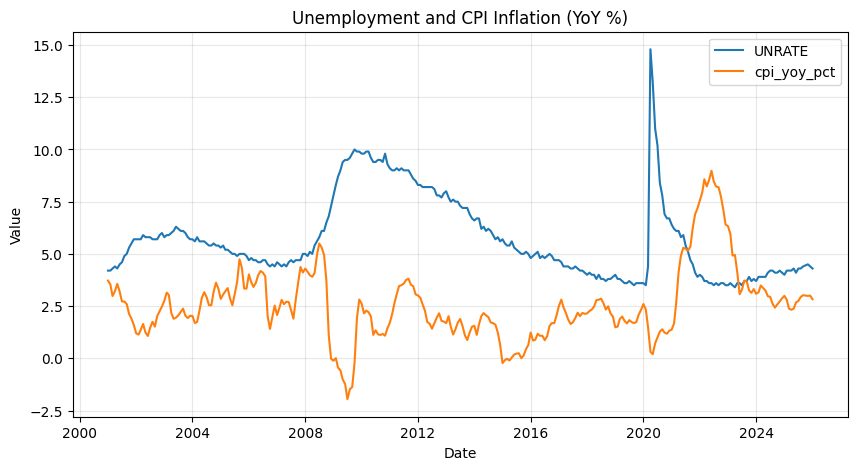

Correlation: -0.42621773897545


In [16]:
def plot_series(df: pd.DataFrame, y_cols: List[str], title: str = "") -> None:
    """Line plot for one or more columns over time."""
    if "date" not in df.columns:
        raise ValueError("Expected a 'date' column.")

    plt.figure()
    for col in y_cols:
        plt.plot(df["date"], df[col], label=col)
    plt.title(title or "Time Series Plot")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def yoy_pct_change(df: pd.DataFrame, col: str) -> pd.Series:
    """Year-over-year percent change (12-month change) for monthly data."""
    return 100 * (df[col] / df[col].shift(12) - 1)

def corr_two(df: pd.DataFrame, col1: str, col2: str) -> float:
    """Correlation using rows where both columns are non-missing."""
    tmp = df.dropna(subset=[col1, col2])
    if len(tmp) < 3:
        return np.nan
    return float(tmp[col1].corr(tmp[col2]))

# --- Example (CPI inflation + unemployment) ---
# TODO: create CPI YoY inflation and plot alongside unemployment
wide = merge_series_list(["UNRATE", "CPIAUCSL"], start_date="2000-01-01")
wide["cpi_yoy_pct"] = yoy_pct_change(wide, "CPIAUCSL")
plot_series(wide.dropna(subset=["cpi_yoy_pct"]), ["UNRATE", "cpi_yoy_pct"],
             title="Unemployment and CPI Inflation (YoY %)")
print("Correlation:", corr_two(wide.dropna(subset=["cpi_yoy_pct"]), "UNRATE", "cpi_yoy_pct"))


✅ **Checkpoint**  
You should have a working toolkit:
- `fred_get_series()`
- `merge_series_list()`
- `plot_series()`
- `yoy_pct_change()`
- `corr_two()`

Tomorrow we’ll connect an LLM “brain” and practice getting **structured plans** from it.


# 2 — Add the LLM “brain” (OpenAI API) + structured prompting

Goal is to learn a clean way to ask an LLM to output:
- a **plan** (what to do)
- optionally a **tool call** (what function to run)
- a **short explanation** in plain English

We will use the OpenAI **Responses API** (current primary API).
Reference: OpenAI Python API docs. citeturn0search12turn0search5turn0search0


## 2.1) OpenAI client setup

If `OPENAI_API_KEY` is available, this will work.
If not, use the **mock LLM** below so you can still complete the rest of the logic.


In [18]:
USE_REAL_LLM = bool(OPENAI_API_KEY)

if USE_REAL_LLM:
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    print("Using REAL LLM via OpenAI API.")
else:
    client = None
    print("No OpenAI key found. Using MOCK LLM.")

def mock_llm_json(prompt: str) -> Dict[str, Any]:
    """A deterministic 'fake' model output to let you test your agent logic without an API key."""
    # Very simple heuristic for demo purposes
    q = prompt.lower()
    if "unemployment" in q and "inflation" in q:
        return {
            "tool": "build_dataset",
            "args": {"series_ids": ["UNRATE", "CPIAUCSL"], "start_date": "2000-01-01"},
            "analysis_steps": ["download series", "compute CPI YoY", "plot", "correlation"],
            "narrative": "I will download unemployment and CPI, compute YoY CPI inflation, plot them, and report their correlation."
        }
    return {
        "tool": None,
        "args": {},
        "analysis_steps": ["answer conceptually"],
        "narrative": "I will answer conceptually without calling tools."
    }


Using REAL LLM via OpenAI API.


In [19]:
resp = client.responses.create(
    model="gpt-4.1-mini",
    input="In one sentence, what is inflation?"
)

print(resp.output_text)

Inflation is the rate at which the general level of prices for goods and services rises, causing the purchasing power of money to decrease.


## 2.2) Ask the LLM for a structured plan (JSON)

We will ask the model to output a JSON object with:
- `tool`: name of tool to call (or null)
- `args`: tool arguments (dictionary)
- `analysis_steps`: short list of steps
- `narrative`: 2–4 sentences for the user

This keeps the agent **predictable**.


In [22]:
PLANNER_SYSTEM_INSTRUCTIONS = """You are an assistant for an economics data tools class.
You must respond ONLY with valid JSON (no markdown, no extra text).
Schema:
{
  "tool": "build_dataset" | "analyze_dataset" | null,
  "args": { ... },
  "analysis_steps": [ "...", "..."],
  "narrative": "..."
}

Rules:
- If the user asks to fetch time-series data, pick tool "build_dataset".
- If the user asks to compute statistics/plots on an existing DataFrame, pick tool "analyze_dataset".
- If the user asks conceptual questions (no data), set tool=null.
- Keep narrative short and friendly (2–4 sentences).
"""

def llm_plan(question: str) -> Dict[str, Any]:
    prompt = f"User question: {question}"

    if USE_REAL_LLM:
        # OpenAI Responses API (recommended). citeturn0search5turn0search12
        resp = client.responses.create(
            model="gpt-4.1-mini",
            instructions=PLANNER_SYSTEM_INSTRUCTIONS,
            input=prompt
        )
        # The SDK returns output items; easiest is to use output_text for text content.
        txt = resp.output_text
        return json.loads(txt)
    else:
        return mock_llm_json(prompt)

# --- Test ---
plan = llm_plan("Plot unemployment and inflation since 2000 and tell me if they move together.")
plan


{'tool': 'build_dataset',
 'args': {'indicators': ['unemployment_rate', 'inflation_rate'],
  'start_year': 2000,
  'end_year': 2024},
 'analysis_steps': ['Download annual unemployment and inflation rate data from 2000 to 2024.',
  'Plot both time series on the same graph for visual comparison.',
  'Assess correlation between unemployment and inflation rates over this period.'],
 'narrative': 'I will gather unemployment and inflation data from 2000 onwards, create a combined plot, and then check if their trends typically move together or diverge.'}

# 3 — Tool-using agent loop (LLM chooses → Python executes → LLM explains)

Build the actual agent:
1. Ask the LLM for a plan (JSON)
2. If a tool is requested, run the tool in Python
3. Produce a final response

We will keep tools limited on purpose (good for teaching + grading).


## 3.1) Define the tools your agent is allowed to use

Tool 1: `build_dataset(series_ids, start_date)`  
- downloads series
- computes CPI YoY if CPI is present
- returns a DataFrame

Tool 2: `analyze_dataset(df, tasks)`  
- tasks can include: plot, correlation, summary


In [24]:
def tool_build_dataset(series_ids: List[str], start_date: str = "2000-01-01") -> pd.DataFrame:
    df = merge_series_list(series_ids, start_date=start_date)

    # Optional: compute CPI YoY if CPIAUCSL is present
    if "CPIAUCSL" in df.columns:
        df["cpi_yoy_pct"] = yoy_pct_change(df, "CPIAUCSL")
    return df

def tool_analyze_dataset(df: pd.DataFrame, tasks: List[str]) -> Dict[str, Any]:
    out: Dict[str, Any] = {}

    if "plot" in tasks:
        # choose numeric columns (except date)
        y_cols = [c for c in df.columns if c != "date" and pd.api.types.is_numeric_dtype(df[c])]
        plot_series(df.dropna(how="all", subset=y_cols), y_cols[:3], title="Agent Plot (first 3 numeric cols)")
        out["plotted_cols"] = y_cols[:3]

    if "correlation" in tasks:
        # Example: correlate UNRATE with cpi_yoy_pct if available
        if "UNRATE" in df.columns and "cpi_yoy_pct" in df.columns:
            out["corr_unrate_cpi_yoy"] = corr_two(df.dropna(subset=["cpi_yoy_pct"]), "UNRATE", "cpi_yoy_pct")

    if "summary" in tasks:
        out["summary"] = df.describe(include="all").to_dict()

    return out


In [26]:
def resample_to_monthly(df: pd.DataFrame, col: str, how: str = "mean") -> pd.DataFrame:
    """
    Resample a daily (or higher frequency) series to monthly.
    how: 'mean' (monthly average) or 'last' (end-of-month).
    Returns a DataFrame with month-start dates for clean merges.
    """
    tmp = df[["date", col]].dropna().copy()
    tmp["month"] = tmp["date"].dt.to_period("M").dt.to_timestamp()  # month start
    
    if how == "mean":
        out = tmp.groupby("month", as_index=False)[col].mean()
    elif how == "last":
        out = tmp.sort_values("date").groupby("month", as_index=False)[col].last()
    else:
        raise ValueError("how must be 'mean' or 'last'")
        
    out = out.rename(columns={"month": "date"})
    return out

## 3.2) The agent function

This function:
- gets a plan from the LLM
- calls tools if requested
- returns a final dictionary with:
  - plan
  - data (optional)
  - tool outputs (optional)
  - final message to user (text)


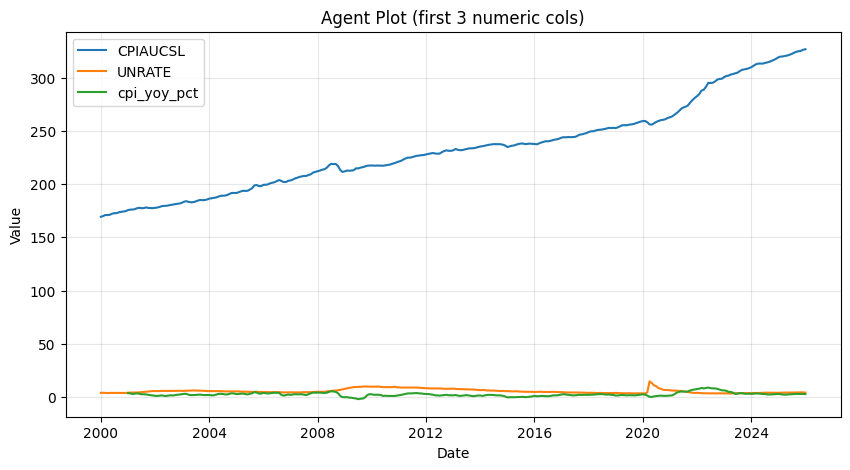

('I will gather monthly data for unemployment and inflation since 2000, calculate inflation rates, and plot both. Then, we can visually inspect whether the two variables move together over time.',
 {'plotted_cols': ['CPIAUCSL', 'UNRATE', 'cpi_yoy_pct'],
  'corr_unrate_cpi_yoy': -0.42621773897545})

In [28]:
def economic_agent(question: str) -> Dict[str, Any]:
    plan = llm_plan(question)

    result: Dict[str, Any] = {"question": question, "plan": plan, "tool_output": None}

    tool = plan.get("tool")
    args = plan.get("args", {}) or {}

    df = None

    # ---- Tool execution ----
    if tool == "build_dataset":
        series_ids = args.get("series_ids", ["UNRATE", "CPIAUCSL"])
        start_date = args.get("start_date", "2000-01-01")
        df = tool_build_dataset(series_ids=series_ids, start_date=start_date)
        result["data_preview"] = df.head().to_dict(orient="records")

        # Optional default analysis: plot & correlation if available
        tasks = ["plot", "correlation"]
        result["tool_output"] = tool_analyze_dataset(df.dropna(subset=["date"]), tasks=tasks)

    elif tool == "analyze_dataset":
        # TODO: in a more advanced version, you would accept a df already in memory.
        # For this template we keep it simple.
        result["tool_output"] = {"note": "analyze_dataset tool selected, but no dataset was passed in this template."}

    else:
        # tool is null → conceptual answer
        result["tool_output"] = None

    # ---- Final narrative (use plan narrative) ----
    result["final_message"] = plan.get("narrative", "Done.")
    return result

# --- Test the agent ---
out = economic_agent("Plot unemployment and inflation since 2000 and tell me if they move together.")
out["final_message"], out.get("tool_output", None)


---
## ▶️ Run-me demo (should print + plot)

Run this after all cells above have executed.

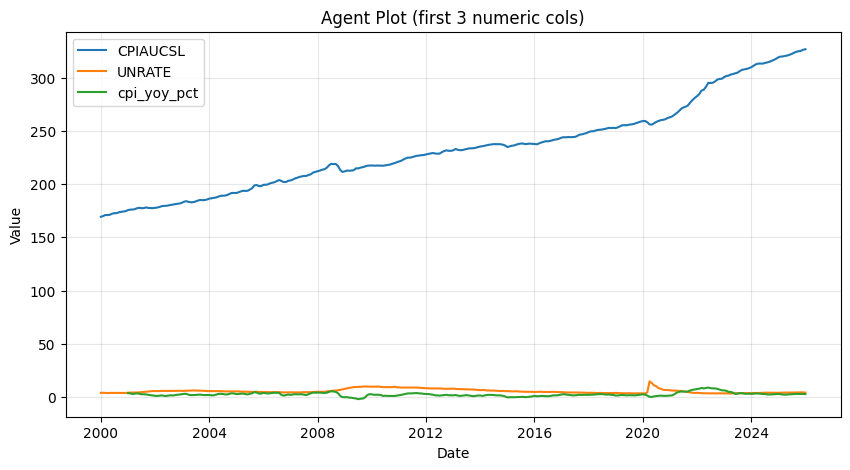

FINAL MESSAGE:
I will first gather unemployment and inflation data from 2000, then plot them to visually inspect if their trends correlate. Lastly, I will quantify their relationship to confirm if they move together.

TOOL OUTPUT (keys): ['plotted_cols', 'corr_unrate_cpi_yoy']
Correlation (if computed): -0.42621773897545


,date,CPIAUCSL,UNRATE,cpi_yoy_pct
0,2000-01-01,169.3,4.0,NaN
1,2000-02-01,170.0,4.1,NaN
2,2000-03-01,171.0,4.0,NaN
3,2000-04-01,170.9,3.8,NaN
4,2000-05-01,171.2,4.0,NaN


In [30]:
# NOTE: This will call the LLM planner and then pull FRED data.
# If you want a no-cost/no-billing demo, set USE_REAL_LLM = False above.

question = "Plot unemployment and inflation since 2000 and tell me if they move together."
out = economic_agent(question)

print("FINAL MESSAGE:")
print(out.get("final_message", ""))

print("\nTOOL OUTPUT (keys):", list((out.get("tool_output") or {}).keys()))
print("Correlation (if computed):", (out.get("tool_output") or {}).get("corr_unrate_cpi_yoy", None))

# Show a preview of the merged data (first 5 rows)
preview = out.get("data_preview", [])
if preview:
    display(pd.DataFrame(preview))

# ✅ Two Agent Versions (Easy → Intermediate)

In this notebook you will build **two versions** of an AI economic data agent.

## Version 1 — Easy (Baseline)
- Uses a very simple planner (or mock planner)
- Hard-coded default series when needed
- Great for learning the architecture

## Version 2 — Intermediate (More Autonomous)
- The LLM **maps concepts → series IDs** from an approved dictionary
- The LLM chooses transformations (e.g., YoY inflation)
- The agent feels much more “autonomous” while staying **safe and gradeable**


## Version 1 — Easy Agent (Baseline)

Run this first. It is intentionally simple and reliable.

### Try:
- `"Plot unemployment and inflation since 2000 and tell me if they move together."`
- `"Show me unemployment since 2015."`


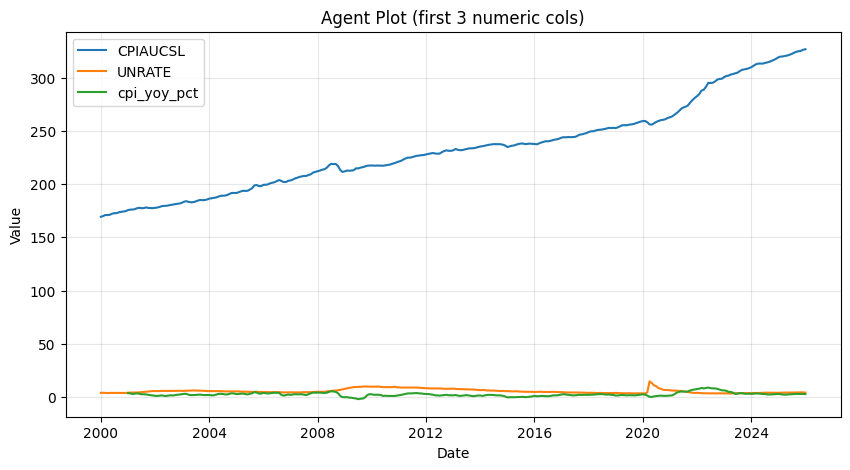

V1 FINAL MESSAGE:
Let's look at the unemployment and inflation rates since 2000 by plotting them together and checking their correlation. This will help us understand if these two variables tend to move in the same direction over time.

V1 TOOL OUTPUT (keys): ['plotted_cols', 'corr_unrate_cpi_yoy']
V1 Correlation (if computed): -0.42621773897545


,date,CPIAUCSL,UNRATE,cpi_yoy_pct
0,2000-01-01,169.3,4.0,NaN
1,2000-02-01,170.0,4.1,NaN
2,2000-03-01,171.0,4.0,NaN
3,2000-04-01,170.9,3.8,NaN
4,2000-05-01,171.2,4.0,NaN


In [32]:
# Version 1 demo (baseline agent)
question_v1 = "Plot unemployment and inflation since 2000 and tell me if they move together."
out_v1 = economic_agent(question_v1)

print("V1 FINAL MESSAGE:")
print(out_v1.get("final_message", ""))

print("\nV1 TOOL OUTPUT (keys):", list((out_v1.get("tool_output") or {}).keys()))
print("V1 Correlation (if computed):", (out_v1.get("tool_output") or {}).get("corr_unrate_cpi_yoy", None))

preview = out_v1.get("data_preview", [])
if preview:
    display(pd.DataFrame(preview))

---

## Version 2 — Intermediate Agent (More Autonomous)

### What changes?
Instead of hard-coding series IDs, we give the LLM a **menu** of approved series and ask it to:

1. Identify requested concepts (e.g., inflation, unemployment, GDP)
2. Map concepts → FRED series IDs from a dictionary (no hallucinated IDs)
3. Choose tasks (plot, correlation, summary)
4. Choose transformations (YoY for CPI or GDP)

This makes the agent feel much more autonomous while keeping it controlled.


### 2.1 Approved series menu (safe)
Add or remove series to match your course content.


In [34]:
# Approved dictionary: concept -> FRED series id
# Keep this small for teaching + grading; expand later if you want.
APPROVED_SERIES = {
    "unemployment": "UNRATE",
    "inflation": "CPIAUCSL",
    "cpi": "CPIAUCSL",
    "gdp": "GDP",
    "real gdp": "GDPC1",
    "federal funds rate": "DFF",
    "interest rate": "DFF",
    "oil price": "DCOILWTICO",
    "oil": "DCOILWTICO",
    "wages": "CES0500000003",  # Avg hourly earnings, total private (one common choice)
    "jobs": "PAYEMS",          # Total nonfarm payrolls
}

APPROVED_CONCEPTS = sorted(set(APPROVED_SERIES.keys()))
APPROVED_SERIES_IDS = sorted(set(APPROVED_SERIES.values()))

print("Approved concepts:", APPROVED_CONCEPTS)
print("Approved series IDs:", APPROVED_SERIES_IDS)

Approved concepts: ['cpi', 'federal funds rate', 'gdp', 'inflation', 'interest rate', 'jobs', 'oil', 'oil price', 'real gdp', 'unemployment', 'wages']
Approved series IDs: ['CES0500000003', 'CPIAUCSL', 'DCOILWTICO', 'DFF', 'GDP', 'GDPC1', 'PAYEMS', 'UNRATE']


### 2.2 Planner v2 (JSON)
This planner returns a structured plan your code can execute.

**Important:** The model must choose series IDs only from the approved list.


In [36]:
PLANNER_V2_INSTRUCTIONS = f"""You are an AI economic data agent planner for an economics data tools class.

Return ONLY valid JSON (no markdown, no extra text).

You must choose FRED series ONLY from this approved list:
{APPROVED_SERIES_IDS}

You may map user concepts to series IDs using this concept map:
{APPROVED_SERIES}

Schema:
{{
  "series_ids": ["..."],              // choose from approved series IDs
  "start_date": "YYYY-MM-DD",         // default "2000-01-01" unless user specifies
  "compute_yoy_for": ["..."],         // subset of series_ids where YoY makes sense
  "tasks": ["plot", "correlation"],   // allowed: plot, correlation, summary
  "narrative": "2–5 sentence interpretation plan in plain English"
}}

Rules:
- Always include "plot" in tasks.
- Include "correlation" when there are 2+ series.
- If the user asks about inflation and CPIAUCSL is selected, include CPIAUCSL in compute_yoy_for.
- If GDP or GDPC1 is selected and growth language is implied, include it in compute_yoy_for.
- If user mentions a date range, respect it; otherwise start_date="2000-01-01".
- If a user request is unclear, choose the closest relevant 1–2 series from the approved list.
"""

def llm_plan_v2(question: str) -> Dict[str, Any]:
    prompt = f"User question: {question}"
    if USE_REAL_LLM:
        resp = client.responses.create(
            model="gpt-4.1-mini",
            instructions=PLANNER_V2_INSTRUCTIONS,
            input=prompt,
            max_output_tokens=350,
        )
        txt = resp.output_text
        return json.loads(txt)
    else:
        # Simple mock output for v2
        q = question.lower()
        series = []
        if "unemploy" in q:
            series.append("UNRATE")
        if "inflation" in q or "cpi" in q:
            series.append("CPIAUCSL")
        if not series:
            series = ["UNRATE"]
        return {
            "series_ids": series,
            "start_date": "2000-01-01",
            "compute_yoy_for": ["CPIAUCSL"] if "CPIAUCSL" in series else [],
            "tasks": ["plot", "correlation"] if len(series) >= 2 else ["plot"],
            "narrative": "I will download the requested series, compute YoY inflation if CPI is included, plot the data, and report correlation when applicable."
        }

### 2.3 Wow agent executor
This is the “autonomous-feeling” agent loop:
LLM plan → download data → compute transformations → analyze → short narrative.


In [38]:
def economic_agent_wow(question: str) -> Dict[str, Any]:
    plan = llm_plan_v2(question)

    series_ids = plan.get("series_ids", [])
    start_date = plan.get("start_date", "2000-01-01")
    compute_yoy_for = plan.get("compute_yoy_for", [])
    tasks = plan.get("tasks", ["plot"])

    # Safety check: enforce approved series
    series_ids = [sid for sid in series_ids if sid in APPROVED_SERIES_IDS]
    if not series_ids:
        series_ids = ["UNRATE"]

    df = tool_build_dataset(series_ids=series_ids, start_date=start_date)

    # --- Frequency alignment (important for daily series like oil) ---
    if "DCOILWTICO" in df.columns:
        oil_monthly = resample_to_monthly(df, "DCOILWTICO", how="mean")

        keep_cols = [
            c for c in df.columns
            if c in ["date", "CPIAUCSL", "cpi_yoy_pct", "CPIAUCSL_yoy_pct"]
        ]

        df_monthly_base = df[keep_cols].dropna(subset=["CPIAUCSL"], how="any").copy()

        df = (
            df_monthly_base
            .merge(oil_monthly, on="date", how="left")
            .sort_values("date")
            .reset_index(drop=True)
        )

    # --- Transformations: YoY ---
    for sid in compute_yoy_for:
        if sid in df.columns:
            df[f"{sid}_yoy_pct"] = yoy_pct_change(df, sid)

    # --- Choose plot columns ---
    plot_cols = []
    for sid in series_ids:
        yoy_col = f"{sid}_yoy_pct"
        if yoy_col in df.columns:
            plot_cols.append(yoy_col)
        elif sid in df.columns:
            plot_cols.append(sid)

    analysis_out = {}

    if "plot" in tasks:
        plot_df = df.dropna(subset=plot_cols, how="any") if plot_cols else df.dropna()
        plot_series_plotly(plot_df, plot_cols[:3], title="Wow Agent: Selected Indicators (Plotly)")
        analysis_out["plotted_cols"] = plot_cols[:3]

    if "correlation" in tasks and len(plot_cols) >= 2:
        analysis_out["correlation"] = corr_two(
            df.dropna(subset=plot_cols[:2]),
            plot_cols[0],
            plot_cols[1]
        )

    if "summary" in tasks:
        analysis_out["summary"] = df.describe().to_dict()

    return {
        "question": question,
        "plan": plan,
        "series_ids_used": series_ids,
        "analysis": analysis_out,
        "data": df, 
        "data_preview": df.head().to_dict(orient="records"),
        "final_message": plan.get("narrative", "")
    }

### 2.4 Intermediate demos

These are designed to impress because you can change the question and the agent adapts.


In [46]:
# DEMO 1
q1 = "Is there evidence of a Phillips Curve since 1990? (use unemployment and inflation)"
out_w1 = economic_agent_wow(q1)

print("INTERMEDIATE FINAL MESSAGE:")
print(out_w1["final_message"])
print("\nSeries used:", out_w1["series_ids_used"])
print("Correlation (if computed):", out_w1["analysis"].get("correlation", None))

df_full = out_w1["data"]
display(df_full[df_full["date"] >= "2016-01-01"])

#display(pd.DataFrame(out_w1["data_preview"]))

INTERMEDIATE FINAL MESSAGE:
This plan will analyze the relationship between unemployment and inflation from 1990 onwards to examine evidence of the Phillips Curve. We will plot both series with year-over-year inflation to observe their trends and compute correlations to identify any inverse relationship consistent with the Phillips Curve hypothesis.

Series used: ['UNRATE', 'CPIAUCSL']
Correlation (if computed): -0.3440474882120544


series_id,date,CPIAUCSL,UNRATE,cpi_yoy_pct,CPIAUCSL_yoy_pct
312,2016-01-01,237.652,4.8,1.237503,1.237503
313,2016-02-01,237.336,4.9,0.847278,0.847278
314,2016-03-01,238.080,5.0,0.891616,0.891616
315,2016-04-01,238.992,5.1,1.172626,1.172626
316,2016-05-01,239.557,4.8,1.078476,1.078476
...,...,...,...,...,...
427,2025-08-01,323.291,4.3,2.938592,2.938592
428,2025-09-01,324.245,4.4,3.022572,3.022572
429,2025-11-01,325.063,4.5,2.988300,2.988300
430,2025-12-01,326.031,4.4,3.002262,3.002262


In [48]:
# WOW DEMO 2
q2 = "Compare oil prices and inflation after 2015. Do they move together? Use data starting in 2010 so YoY can be computed."
out_w2 = economic_agent_wow(q2)

print("WOW FINAL MESSAGE:")
print(out_w2["final_message"])
print("\nSeries used:", out_w2["series_ids_used"])
print("Correlation (if computed):", out_w2["analysis"].get("correlation", None))

df_full = out_w2["data"]
display(df_full[df_full["date"] >= "2016-01-01"])
#display(pd.DataFrame(out_w2["data_preview"]))

WOW FINAL MESSAGE:
This analysis will plot the trends in oil prices and inflation from 2010 onward and compute the year-over-year change for inflation to better capture its movement. The correlation task will determine whether changes in oil prices and inflation tend to move together, highlighting their relationship over this period.

Series used: ['DCOILWTICO', 'CPIAUCSL']
Correlation (if computed): 0.4458159750621705


,date,CPIAUCSL,cpi_yoy_pct,DCOILWTICO,CPIAUCSL_yoy_pct
72,2016-01-01,237.652,NaN,31.683158,1.237503
73,2016-02-01,237.336,NaN,30.323000,0.847278
74,2016-03-01,238.080,NaN,37.546364,0.891616
75,2016-04-01,238.992,NaN,40.755238,1.172626
76,2016-05-01,239.557,NaN,46.712381,1.078476
...,...,...,...,...,...
187,2025-08-01,323.291,NaN,64.864286,2.938592
188,2025-09-01,324.245,NaN,63.959048,3.022572
189,2025-11-01,325.063,NaN,60.062222,2.988300
190,2025-12-01,326.031,NaN,57.972273,3.002262


 Version 2 feels autonomous because the model is doing structured decision-making:
- choosing series
- choosing transformations
- choosing tasks

But it’s still controlled because it can only use approved series IDs and approved tools.
